# Introducción 
+ Extensión de python: py
+ Extensión de notebook: .ipynb

Símbolo de la terminal
# Bash
```
$ cat
```


Command Prompt | Power Shell
```
> cd
```

Python
```
>>> print("Hola mundo")
````


### Dividir el problema en pasos
+ Necesito tokens, precio
+ tokens: lista de 0 a 1 millón

- Puntos de referencia:
 |-- (0, 0 USD)
 |-- (300,000 tokens, 10 USD)
 |-- (1,000,000 tokens, 45 USD)

- Precio(tokens): 
 |-- 0.0000316 × tokens si tokens <= 272000
 |-- 0.00005 × tokens - 5 si tokens > 272000

30 * (272k)/(1 millón de tokens) = 8.16


In [4]:
import numpy as np

In [6]:
# Crea la lista en memoria (0 a 1,000,000)
tokens = list(range(1000001))


In [8]:
print(tokens[:10])
tokens[-10:]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


[999991,
 999992,
 999993,
 999994,
 999995,
 999996,
 999997,
 999998,
 999999,
 1000000]

In [22]:
# Convertir a numpy array para operaciones vectorizadas
tokens_array = np.array(tokens)

# Crear array de precios usando where
precios = np.where(
    tokens_array <= 272000,
    0.0000316 * tokens_array,           # Short context
    0.00005 * tokens_array - 5          # Long context
)

# Verificar con los puntos de referencia
print(f"En 0 tokens: {precios[0]:.4f} USD (esperado 0)")
print(f"En 300,000 tokens: {precios[300000]:.4f} USD (esperado 10)")
print(f"En 1,000,000 tokens: {precios[1000000]:.4f} USD (esperado 45)")


En 0 tokens: 0.0000 USD (esperado 0)
En 300,000 tokens: 10.0000 USD (esperado 10)
En 1,000,000 tokens: 45.0000 USD (esperado 45)


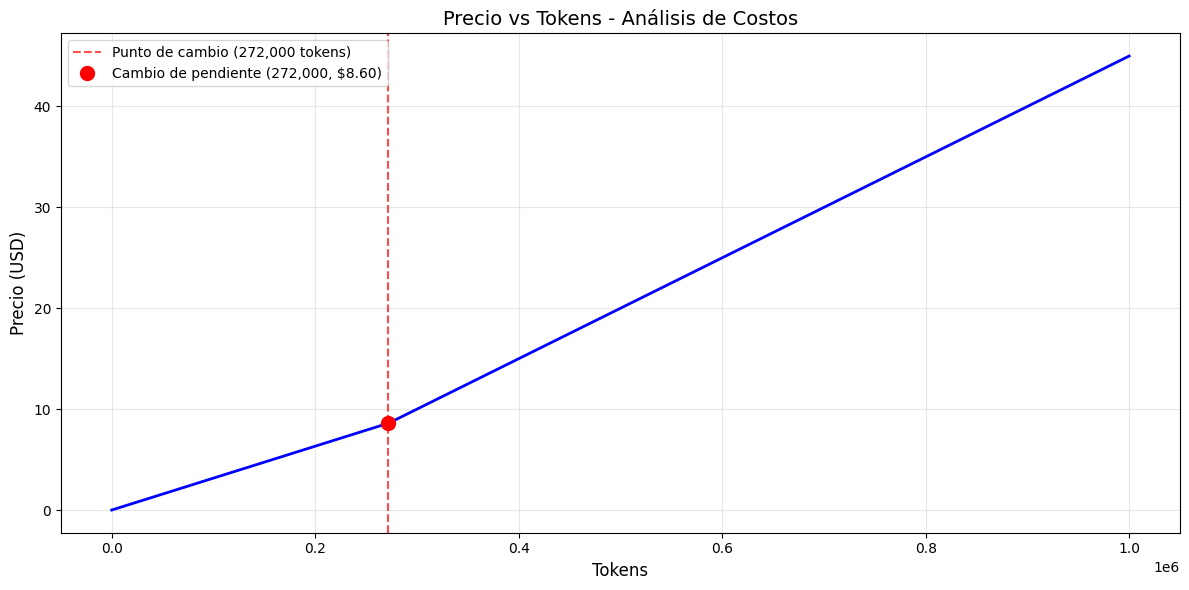

In [24]:
import matplotlib.pyplot as plt

# Calcular el precio en el punto de cambio
punto_cambio_tokens = 272000
punto_cambio_precio = 0.0000316 * punto_cambio_tokens

plt.figure(figsize=(12, 6))
plt.plot(tokens_array, precios, linewidth=2, color='blue')
plt.axvline(x=272000, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Punto de cambio (272,000 tokens)')

# Marcar el punto medio donde cambia la pendiente
plt.plot(punto_cambio_tokens, punto_cambio_precio, 'ro', markersize=10, label=f'Cambio de pendiente ({punto_cambio_tokens:,}, ${punto_cambio_precio:.2f})')

plt.xlabel('Tokens', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.title('Precio vs Tokens - Análisis de Costos', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
